In [1]:
import Pkg
Pkg.activate("/home/matteo/Projects/OU_inference/")

  Activating project at `~/Projects/OU_inference`


In [2]:
using Revise

In [3]:
using DiffusionEvolution, LinearAlgebra, PyPlot

Precompiling DiffusionEvolution
  ✓ Zygote → ZygoteDistancesExt
  ✓ Flux
  ✓ DiffusionEvolution
  3 dependencies successfully precompiled in 74 seconds. 176 already precompiled.
[ Info: Precompiling DiffusionEvolution [fede2d61-eba6-4945-aa96-3bfe712f026f]
Precompiling ZygoteColorsExt
  ✓ Zygote → ZygoteColorsExt
  1 dependency successfully precompiled in 29 seconds. 78 already precompiled.
[ Info: Precompiling ZygoteColorsExt [e68c091a-8ea5-5ca7-be4f-380657d4ad79]
┌ Warning: Module Zygote with build ID fafbfcfd-d3e4-ad20-0000-6c0e3ea3a04a is missing from the cache.
│ This may mean Zygote [e88e6eb3-aa80-5325-afca-941959d7151f] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:1948
[ Info: Skipping precompilation since __precompile__(false). Importing ZygoteColorsExt [e68c091a-8ea5-5ca7-be4f-380657d4ad79].


In [4]:
const de = DiffusionEvolution

DiffusionEvolution

In [5]:
import PyPlot.subplots
subplots(x,y,d) = subplots(x, y, figsize=(y*d, x*d))

subplots (generic function with 2 methods)

In [6]:
d = 10
nsamples = 1000
T = 50

50

In [28]:
β = 0.05

0.05

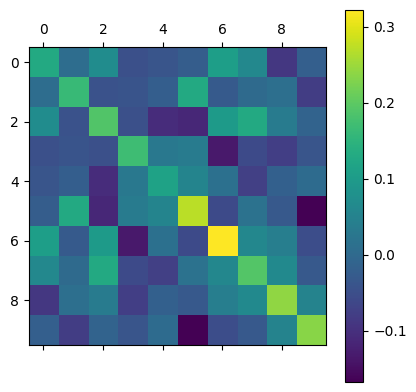

PyObject <matplotlib.colorbar.Colorbar object at 0x76e9a81e8c70>

In [29]:
m = randn(d,d)
J = (m * m') * (β/sqrt(d))
matshow(J)
colorbar()

In [30]:
θ = randn(d)
θ ./= norm(θ)
θ .*= 10*d

10-element Vector{Float64}:
  15.404547035303546
 -69.72690367003752
  46.11015429487354
 -20.52814005082547
  15.447468484998778
  18.71512572817949
 -30.793791236100915
   2.9088900441420695
  20.425711232544455
  19.7610439812708

In [76]:
γ = 0.04

0.04

In [77]:
x_sim = simulate_ou_process(J, θ, γ, nsamples=nsamples, T=T, err_sym=1e-6);

Σ has been symmetrized


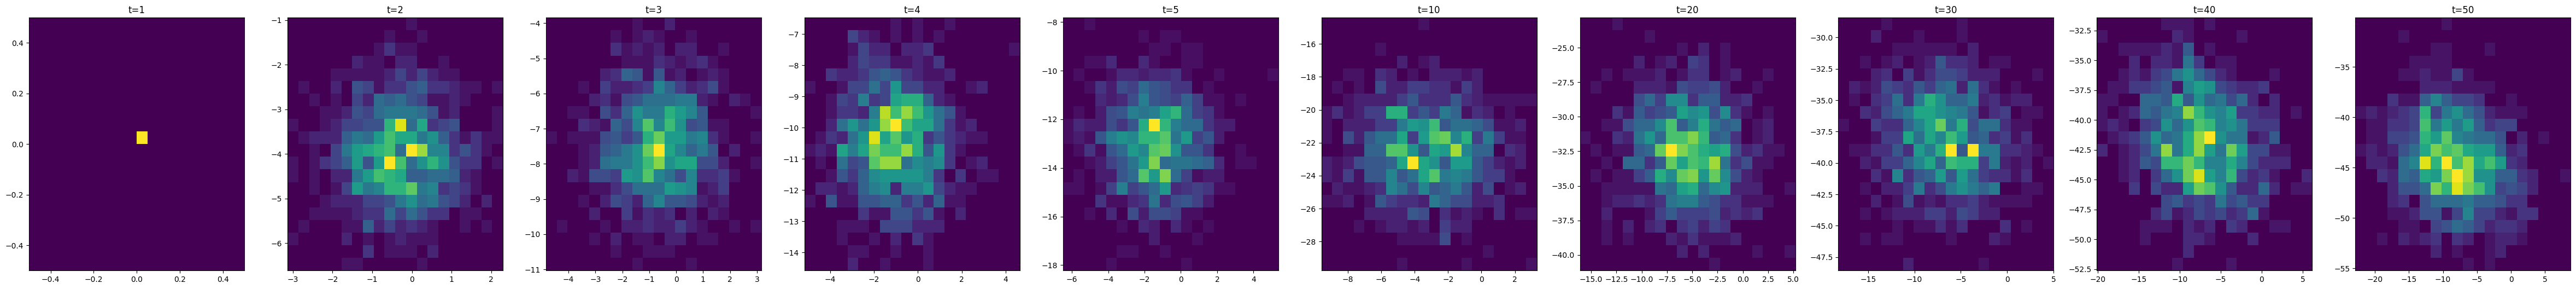

In [78]:
t_view = [1,2,3,4,5,10,20,30,40,50]
fig, ax =subplots(1, length(t_view), 6)
for i in eachindex(t_view)
    ax[i].hist2d(x_sim[1,:,t_view[i]], x_sim[2,:,t_view[i]], bins=20)
    ax[i].set_title("t=$(t_view[i])")
end

In [80]:
t_sample = [1,3,5,10]

4-element Vector{Int64}:
  1
  3
  5
 10

# Single thread

In [81]:
data = collect_data(zeros(d), x_sim[:,:,t_sample .+ 1], fill(1.0, nsamples, length(t_sample)), t_sample)

Data([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], DiffusionEvolution.Sample[DiffusionEvolution.Sample([-0.22071771661438228 0.1506516191140433 … -0.8039192648052489 -1.4797606347219832; -4.190831555125374 -4.023286384635465 … -4.547435957382835 -4.643768579128434; … ; 1.293365917744966 1.6121179212934766 … 2.7636839931251305 2.5102008550273243; 3.1855317119377053 1.5047133583191024 … 3.8221676295566036 3.2048128932027296], [0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001  …  0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001]), DiffusionEvolution.Sample([-0.18387457304810306 -0.44088225654832613 … -1.0348262342744938 -3.9817188193700854; -11.578871317659804 -10.689470968338062 … -10.337507739914972 -12.05515876256382; … ; 4.72065784077241 6.666613200510801 … 4.227157120133979 4.098735025929535; 9.860117945932304 6.800794098074257 … 7.009869600206233 8.947946305740878], [0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001  …

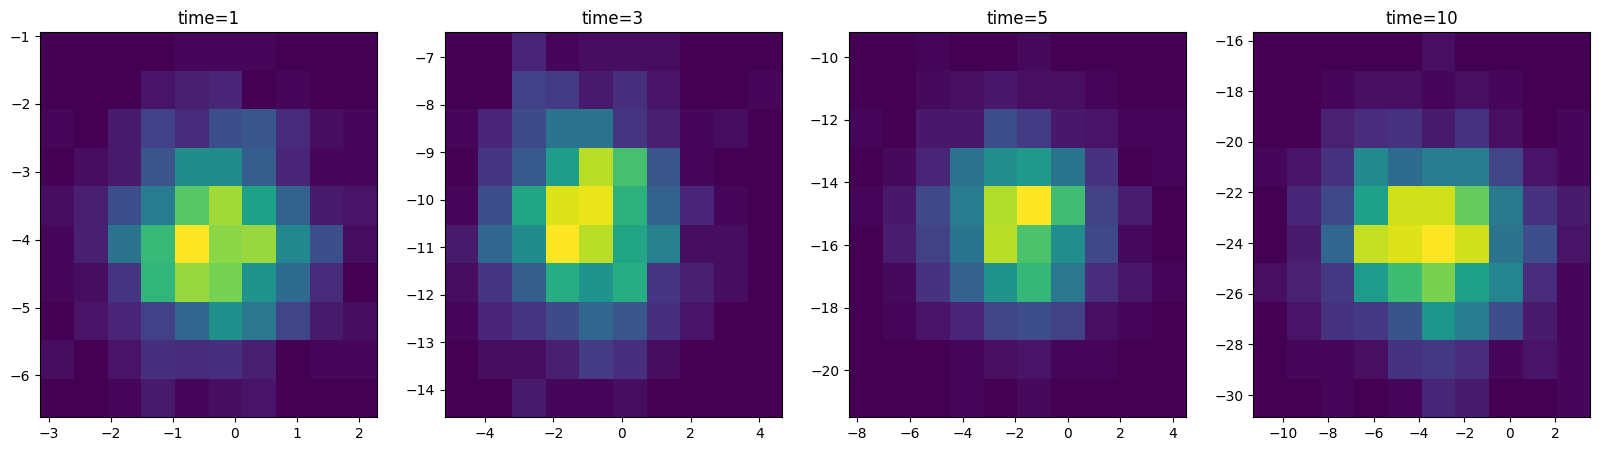

In [82]:
fig, ax = subplots(1, length(data.time), 5)
for i in eachindex(data.time)
    ax[i].hist2d(data.round[i].x[1,:], data.round[i].x[2,:], weights=data.round[i].w)
    ax[i].set_title("time=$(data.time[i])")
end

In [83]:
lambda = 0.01
prior_J = 0.0
prior_theta = 0.0
epsilon = 1e-7
f_tol = 1e-5
x_tol = 1e-5
g_tol = 1e-3

0.001

In [91]:
results = line_search_optimization(data, initialize=length(data.round), n_points=50, iterations =15,
    gamma_upper = 1.0, gamma_lower=0.01,
    lambda=lambda, prior_J=prior_J, prior_theta=prior_theta, epsilon=epsilon,
    f_tol=f_tol, g_tol=g_tol, x_tol=x_tol)

Iteration 1
gamma bounds: (0.01, 1.0)
[0.01, 0.01020620704019996, 0.010421097405359422, 0.010645231370845101, 0.010879218472468916, 0.011123723041997729, 0.01137947050627032, 0.011647254575707155, 0.011927945472249268, 0.012222499376403094, 0.012531969309462918, 0.012857517711886642, 0.013200431034482759, 0.013562136728480488, 0.01394422310756972, 0.014348462664714495, 0.014776839565741858, 0.015231582219459121, 0.01571520205259782, 0.01623053991387877, 0.01678082191780822, 0.017369727047146403, 0.018001469507714918, 0.018680899733130005, 0.01941362916006339, 0.020206185567010312, 0.02106620808254514, 0.022002694207453967, 0.023026315789473683, 0.024149827501232134, 0.02538860103626943, 0.02676133260513381, 0.02829099307159353, 0.03000612369871402, 0.031942633637548894, 0.03414634146341464, 0.03667664670658683, 0.03961196443007275, 0.0430579964850615, 0.04716073147256978, 0.05212765957446809, 0.0582639714625446, 0.06603773584905659, 0.07620528771384136, 0.0900735294117647, 0.1101123595

(Any[ * Status: success

 * Candidate solution
    Final objective value:     1.435700e+02

 * Found with
    Algorithm:     L-BFGS

 * Convergence measures
    |x - x'|               = 1.12e-02 ≰ 1.0e-05
    |x - x'|/|x'|          = 2.96e-04 ≰ 0.0e+00
    |f(x) - f(x')|         = 5.23e-04 ≰ 0.0e+00
    |f(x) - f(x')|/|f(x')| = 3.64e-06 ≤ 1.0e-05
    |g(x)|                 = 6.47e-01 ≰ 1.0e-03

 * Work counters
    Seconds run:   3  (vs limit Inf)
    Iterations:    433
    f(x) calls:    1156
    ∇f(x) calls:   1156
,  * Status: success

 * Candidate solution
    Final objective value:     1.430302e+02

 * Found with
    Algorithm:     L-BFGS

 * Convergence measures
    |x - x'|               = 3.34e-02 ≰ 1.0e-05
    |x - x'|/|x'|          = 9.62e-04 ≰ 0.0e+00
    |f(x) - f(x')|         = 9.92e-04 ≰ 0.0e+00
    |f(x) - f(x')|/|f(x')| = 6.93e-06 ≤ 1.0e-05
    |g(x)|                 = 5.58e-01 ≰ 1.0e-03

 * Work counters
    Seconds run:   3  (vs limit Inf)
    Iterations:    216
    f

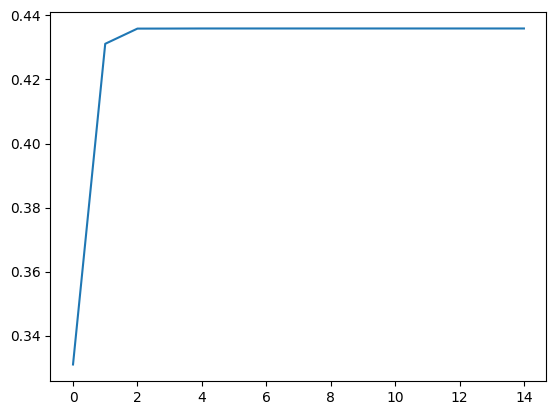

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x76e9b4db2e60>

In [92]:
plot(results[2])

In [93]:
teacher_ene = compute_energy(data.round[end].x, J, θ)
student_ene = compute_energy(data.round[end].x, results[1][end].minimizer, epsilon);

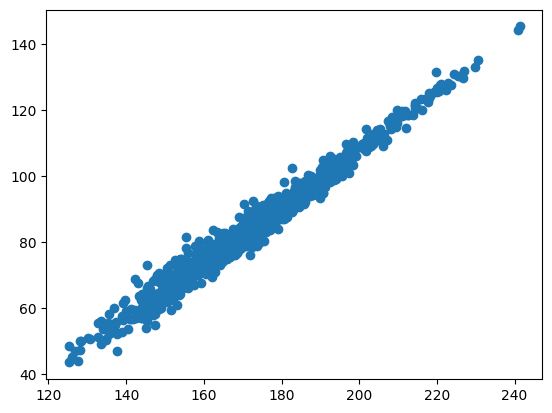

PyObject <matplotlib.collections.PathCollection object at 0x76e9b45998d0>

In [94]:
scatter(teacher_ene, student_ene)

In [50]:
lambda = 0.01
prior_J = 0.0
prior_theta = 0.0
prior_gamma = 0.0
epsilon = 1e-6
eps_conv = 1e-9

1.0e-9

In [95]:
opt_results_gamma = learn_gamma_nlopt(data; initialize=length(t_sample), xtol_abs=eps_conv, xtol_rel=eps_conv, ftol_abs=eps_conv,
    ftol_rel=eps_conv, lambda=lambda, prior_J=prior_J, prior_theta=prior_theta, prior_gamma=prior_gamma, epsilon=epsilon)

(minf = 142.55669463807035, minx = [0.11529751556533085, 0.12450731307106422, 0.0663349653074585, -0.05999841536820168, -0.04926212123375065, 0.14538534766862457, -0.1665266556516805, 0.32670373396372254, -0.07760382093827026, -0.01865565484927569  …  -38.17619591494934, 15.80924428382517, 3.1458643767178422, 1.6467449647399184, -13.435660210796586, -8.904957884030184, 27.659098402736916, 9.872202442487042, 19.14165601863965, 0.4224693219564647], status = :FTOL_REACHED, nevals = 5252, x_start = [0.43546525449012247, 0.913130107530478, 1.3921187533371764, 0.3665624639391612, 0.00039138190118424447, -0.38746880318967875, -1.5984205934399955, 2.098966456179955, 0.2882466944956859, 1.0424349657052152  …  -23.935164937793253, 13.233897478058445, 1.3328441133639541, -2.1693126005988774, -15.653593611432777, -4.43940699715944, 15.78141098064605, 8.443455752094323, 16.059718592285115, 0.1])

In [96]:
opt_results_gamma.minx[end]

0.4224693219564647

In [ ]:
de.log_likelihood_gamma(opt_results_gamma.x_start, data, lambda, prior_J, prior_theta, prior_gamma, epsilon)

In [ ]:
opt_results = learn_nlopt(data; initialize=length(t_sample), xtol_abs=eps_conv, xtol_rel=eps_conv, ftol_abs=eps_conv,
    ftol_rel=eps_conv, prior_x=prior_x, lambda=lambda, epsilon=epsilon, gamma=γ)

In [ ]:
J_inf = de.compute_J(x, d, epsilon)
matshow(J_inf)
colorbar()

In [97]:
teacher_ene = compute_energy(data.round[end].x, J, θ)
student_ene = compute_energy(data.round[end].x, opt_results_gamma.minx, epsilon);

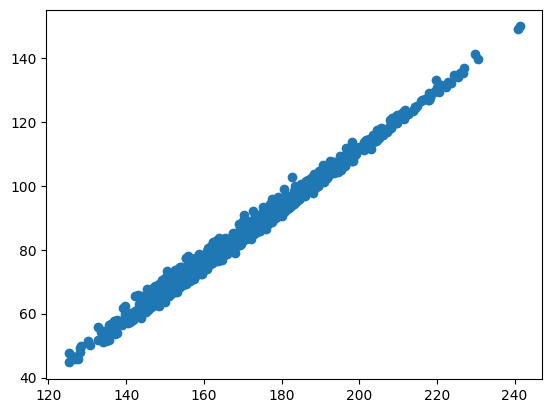

PyObject <matplotlib.collections.PathCollection object at 0x76e99c330ca0>

In [98]:
scatter(teacher_ene, student_ene)

In [ ]:
fig, ax = subplots(1,3,6)
ax[1].scatter(opt_results_gamma.x_start, opt_results_gamma.minx)
ax[2].scatter(opt_results.x_start, opt_results.minx)
ax[3].scatter(opt_results_gamma.minx[1:end-1], opt_results.minx)

In [ ]:
gamma_grid = [0.005, 0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.5, 1.0]
ll_val = zeros(length(gamma_grid))
for i in eachindex(gamma_grid)
    r = learn_nlopt(data; initialize=length(t_sample), xtol_abs=eps_conv, xtol_rel=eps_conv, ftol_abs=eps_conv,
        ftol_rel=eps_conv, prior_x=prior_x, epsilon=epsilon, γ=gamma_grid[i])
    ll_val[i] = r.minf
end

In [ ]:
plot(gamma_grid, ll_val, linestyle="dashed", marker="o")
yscale(:log)
xlabel("gamma")
ylabel("optimal log-likelihood");

In [ ]:
ll_val_gamma = [de.log_likelihood(opt_results_gamma.minx, data, γ, lambda, 0.0, 0.0, epsilon) for γ in gamma_grid]

In [ ]:
plot(gamma_grid, ll_val_gamma, linestyle="dashed", marker="o")
xlabel("gamma")
ylabel("log-likelihood")
yscale(:log)

In [ ]:
de.learn_nlopt_only_gamma(data, x0=opt_results.minx, xtol_abs=eps_conv, xtol_rel=eps_conv, ftol_abs=eps_conv,
    ftol_rel=eps_conv, lambda=lambda, prior_gamma=0.0, epsilon=epsilon) 

In [ ]:
r = de.maximize(data; initialize=0, γ=0.1, xtol_rel=eps_conv, 
    ftol_rel=eps_conv, xtol_abs=eps_conv, ftol_abs=eps_conv, maxtime=-1, maxeval=-1, lambda=lambda,
    prior_x=prior_x, prior_gamma=prior_gamma, epsilon=epsilon, iterations=20);

In [ ]:
r.minγ

In [ ]:
plot(r.ll_iter)
yscale(:log)

In [ ]:
b=de.form_batches(250,30)

In [ ]:
unique(vcat(b...)) |> extrema

# Multithread

In [ ]:
lambda = 0.01
prior_x = 0.01
prior_gamma = 0.01
epsilon = 1e-6
eps_conv = 1e-5

In [ ]:
d_val = [3,5,7,10]

In [ ]:
Threads.@threads for i in eachindex(d_val)
    f = "logs/opt_d$(d_val[i]).txt"
    data = collect_data(zeros(d_val[i]), x_sim[1:d_val[i],:,t_sample], fill(1.0, nsamples, length(t_sample)), t_sample)
    r = iterative_maximization(data; initialize=0, gamma=0.1, xtol_rel=eps_conv, 
        ftol_rel=eps_conv, xtol_abs=eps_conv, ftol_abs=eps_conv, lambda=lambda,
        prior_x=prior_x, prior_gamma=prior_gamma, epsilon=epsilon, iterations=5, logfile=f)
end